# 🏷️ 2.3 — Codificación de Variables Categóricas
## Diplomado en Ciencia Actuarial y Analítica de Seguros

**Objetivo:** Convertir variables de texto a numéricas para modelos predictivos.  
**Variables típicas en seguros:** Tipo de cobertura, municipio, marca de auto, profesión, sexo.


In [129]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
print("✅ Librerías listas")


✅ Librerías listas


In [130]:
# Dataset de pólizas de seguro de auto
np.random.seed(123)
n = 800

municipios = ['Monterrey', 'San Pedro', 'Guadalupe', 'Apodaca', 'Escobedo', 
              'Santa Catarina', 'Juárez', 'García']
coberturas = ['Básica', 'Amplia', 'Total']
niveles_riesgo = ['Bajo', 'Medio', 'Alto']  # Variable ordinal
marcas = ['Toyota', 'Nissan', 'Chevrolet', 'Honda', 'Ford', 'Volkswagen', 
          'Hyundai', 'Kia', 'Mazda', 'Seat']

df = pd.DataFrame({
    'id_poliza': range(1, n+1),
    'municipio': np.random.choice(municipios, n, p=[0.25, 0.15, 0.18, 0.12, 0.08, 0.08, 0.07, 0.07]),
    'tipo_cobertura': np.random.choice(coberturas, n, p=[0.40, 0.35, 0.25]),
    'nivel_riesgo': np.random.choice(niveles_riesgo, n, p=[0.45, 0.35, 0.20]),
    'marca_auto': np.random.choice(marcas, n),
    'sexo': np.random.choice(['M', 'F'], n, p=[0.58, 0.42]),
    'prima_anual': np.random.lognormal(9.8, 0.5, n).clip(5000, 100000),
    'siniestros': np.random.poisson(0.25, n),
})

print(f"📋 Dataset: {df.shape[0]} pólizas, {df.shape[1]} columnas")
print(df.head(8).to_string(index=False))
print(f"\n🔢 Tipos de datos:")
print(df.dtypes)


📋 Dataset: 800 pólizas, 8 columnas
 id_poliza municipio tipo_cobertura nivel_riesgo marca_auto sexo  prima_anual  siniestros
         1   Apodaca         Básica        Medio        Kia    M  5000.000000           0
         2 San Pedro         Amplia         Bajo     Toyota    M 25834.686904           0
         3 Monterrey         Básica         Bajo       Ford    M 26231.886178           0
         4 Guadalupe          Total        Medio       Seat    M 14415.961442           1
         5  Escobedo          Total         Alto     Nissan    M 19146.489391           0
         6 Guadalupe         Amplia         Alto      Mazda    F 20420.004617           0
         7    García         Básica         Bajo     Nissan    F 20841.055198           0
         8   Apodaca          Total         Alto    Hyundai    M 21506.123783           0

🔢 Tipos de datos:
id_poliza           int64
municipio          object
tipo_cobertura     object
nivel_riesgo       object
marca_auto         object
sexo  

## 1. One-Hot Encoding (OHE)

Crea una columna binaria (0/1) por cada categoría.  
⚠️ **Regla:** Se elimina una columna de referencia para evitar la "trampa de la dummy".


In [131]:
# One-Hot Encoding con pandas
print("ANTES:")
print(df[['id_poliza', 'tipo_cobertura']].head(8))

# Método 1: pd.get_dummies (el más sencillo)
dummies_cobertura = pd.get_dummies(df['tipo_cobertura'], prefix='cobertura', drop_first=True)
print("\nDESPUÉS (con drop_first=True — elimina categoría de referencia 'Amplia'):")
print(dummies_cobertura.head(8).astype(int))

# Agregar al dataframe
df_ohe = pd.concat([df, dummies_cobertura], axis=1)
print(f"\n✅ Se crearon {dummies_cobertura.shape[1]} columnas nuevas")
print("   Columna de referencia eliminada: 'cobertura_Amplia'")
print("   Interpretación: cobertura_Básica=0, cobertura_Total=0 → es Amplia")


ANTES:
   id_poliza tipo_cobertura
0          1         Básica
1          2         Amplia
2          3         Básica
3          4          Total
4          5          Total
5          6         Amplia
6          7         Básica
7          8          Total

DESPUÉS (con drop_first=True — elimina categoría de referencia 'Amplia'):
   cobertura_Básica  cobertura_Total
0                 1                0
1                 0                0
2                 1                0
3                 0                1
4                 0                1
5                 0                0
6                 1                0
7                 0                1

✅ Se crearon 2 columnas nuevas
   Columna de referencia eliminada: 'cobertura_Amplia'
   Interpretación: cobertura_Básica=0, cobertura_Total=0 → es Amplia


In [132]:
# OHE para múltiples variables categóricas
vars_categoricas = ['municipio', 'tipo_cobertura', 'sexo']

df_encoded = pd.get_dummies(df, columns=vars_categoricas, drop_first=True, dtype=int)

print(f"Columnas originales: {df.shape[1]}")
print(f"Columnas después de OHE: {df_encoded.shape[1]}")
print(f"Columnas nuevas creadas: {df_encoded.shape[1] - df.shape[1]}")
print("\nNuevas columnas creadas:")
nuevas = [c for c in df_encoded.columns if any(v in c for v in vars_categoricas)]
for c in nuevas:
    print(f"  • {c}")

print(df_encoded.head(8).to_string(index=False))

Columnas originales: 8
Columnas después de OHE: 15
Columnas nuevas creadas: 7

Nuevas columnas creadas:
  • municipio_Escobedo
  • municipio_García
  • municipio_Guadalupe
  • municipio_Juárez
  • municipio_Monterrey
  • municipio_San Pedro
  • municipio_Santa Catarina
  • tipo_cobertura_Básica
  • tipo_cobertura_Total
  • sexo_M
 id_poliza nivel_riesgo marca_auto  prima_anual  siniestros  municipio_Escobedo  municipio_García  municipio_Guadalupe  municipio_Juárez  municipio_Monterrey  municipio_San Pedro  municipio_Santa Catarina  tipo_cobertura_Básica  tipo_cobertura_Total  sexo_M
         1        Medio        Kia  5000.000000           0                   0                 0                    0                 0                    0                    0                         0                      1                     0       1
         2         Bajo     Toyota 25834.686904           0                   0                 0                    0                 0                

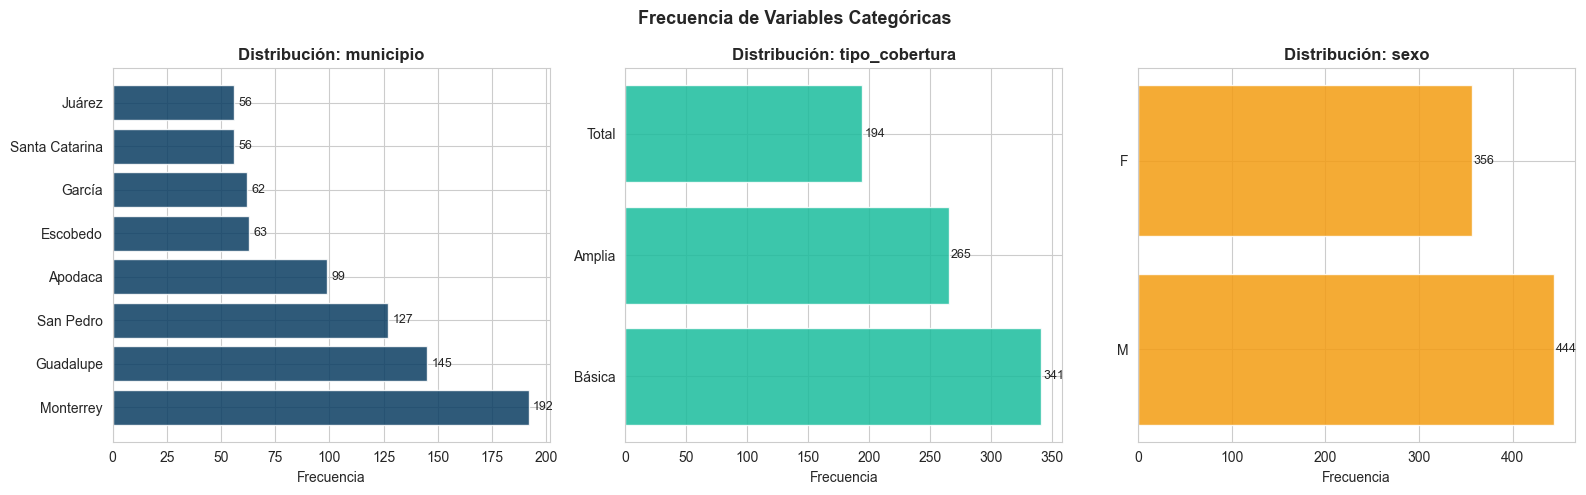

In [133]:
# Visualizar frecuencias de categorías
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
categoricas = ['municipio', 'tipo_cobertura', 'sexo']
colors = ['#0A3D62', '#1ABC9C', '#F39C12']

for ax, col, c in zip(axes, categoricas, colors):
    freq = df[col].value_counts()
    bars = ax.barh(freq.index, freq.values, color=c, alpha=0.85)
    ax.set_title(f'Distribución: {col}', fontweight='bold')
    ax.set_xlabel('Frecuencia')
    for bar, v in zip(bars, freq.values):
        ax.text(v + 2, bar.get_y() + bar.get_height()/2, str(v), va='center', fontsize=9)

plt.suptitle('Frecuencia de Variables Categóricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('categoricas_freq.png', dpi=120, bbox_inches='tight')
plt.show()


## 2. Label Encoding — Para Variables Ordinales

Solo usar cuando las categorías tienen un **orden natural**.  
Ejemplo: Nivel de riesgo (Bajo < Medio < Alto).


In [134]:
# Label Encoding CORRECTO: variables con orden natural
orden_riesgo = {'Bajo': 0, 'Medio': 1, 'Alto': 2}
df['nivel_riesgo_encoded'] = df['nivel_riesgo'].map(orden_riesgo)

print("Variable ordinal con order correcto:")
print(df[['nivel_riesgo', 'nivel_riesgo_encoded']].drop_duplicates().sort_values('nivel_riesgo_encoded'))

# Verificar que el orden tiene sentido actuarial
print("\n📊 Prima promedio por nivel de riesgo:")
print(df.groupby('nivel_riesgo')['prima_anual'].mean().reindex(['Bajo', 'Medio', 'Alto']).apply(lambda x: f'${x:,.0f}'))

# Label Encoding INCORRECTO: variables sin orden
le = LabelEncoder()
df['municipio_le_incorrecto'] = le.fit_transform(df['municipio'])
print("\n⚠️  Label Encoding INCORRECTO en municipio (sin orden natural):")
for mun, code in zip(le.classes_, range(len(le.classes_))):
    print(f"   {mun} → {code}  ← ¿tiene sentido que Apodaca=0 < García=3?")


Variable ordinal con order correcto:
  nivel_riesgo  nivel_riesgo_encoded
1         Bajo                     0
0        Medio                     1
4         Alto                     2

📊 Prima promedio por nivel de riesgo:
nivel_riesgo
Bajo     $20,797
Medio    $19,747
Alto     $21,057
Name: prima_anual, dtype: object

⚠️  Label Encoding INCORRECTO en municipio (sin orden natural):
   Apodaca → 0  ← ¿tiene sentido que Apodaca=0 < García=3?
   Escobedo → 1  ← ¿tiene sentido que Apodaca=0 < García=3?
   García → 2  ← ¿tiene sentido que Apodaca=0 < García=3?
   Guadalupe → 3  ← ¿tiene sentido que Apodaca=0 < García=3?
   Juárez → 4  ← ¿tiene sentido que Apodaca=0 < García=3?
   Monterrey → 5  ← ¿tiene sentido que Apodaca=0 < García=3?
   San Pedro → 6  ← ¿tiene sentido que Apodaca=0 < García=3?
   Santa Catarina → 7  ← ¿tiene sentido que Apodaca=0 < García=3?


In [135]:
df_ejercicio = df.copy()

## 3. Target Encoding — Para Alta Cardinalidad

Reemplaza cada categoría con el **promedio de la variable objetivo** para esa categoría.  
⚠️ Solo calcular con datos de entrenamiento para evitar Data Leakage.


In [136]:
# Target Encoding: municipio → tasa de siniestralidad
# Calcular tasa de siniestralidad por municipio
df['tiene_siniestro'] = (df['siniestros'] > 0).astype(int)

target_encoding = df.groupby('municipio')['tiene_siniestro'].agg(['mean', 'count'])
target_encoding.columns = ['tasa_siniestralidad', 'num_polizas']
target_encoding = target_encoding.sort_values('tasa_siniestralidad', ascending=False)

print("📊 Target Encoding por Municipio:")
print(target_encoding.round(4))

# Aplicar al dataframe
mapa_encoding = target_encoding['tasa_siniestralidad'].to_dict()
df['municipio_target_encoded'] = df['municipio'].map(mapa_encoding)

print(f"\n✅ Municipio codificado con tasa de siniestralidad")
print(df[['municipio', 'municipio_target_encoded']].drop_duplicates().sort_values('municipio_target_encoded', ascending=False))


📊 Target Encoding por Municipio:
                tasa_siniestralidad  num_polizas
municipio                                       
Guadalupe                    0.2828          145
Escobedo                     0.2540           63
San Pedro                    0.2441          127
Apodaca                      0.2424           99
Monterrey                    0.2083          192
García                       0.1935           62
Santa Catarina               0.1786           56
Juárez                       0.1429           56

✅ Municipio codificado con tasa de siniestralidad
         municipio  municipio_target_encoded
3        Guadalupe                  0.282759
4         Escobedo                  0.253968
1        San Pedro                  0.244094
0          Apodaca                  0.242424
2        Monterrey                  0.208333
6           García                  0.193548
21  Santa Catarina                  0.178571
37          Juárez                  0.142857


In [137]:
# Target Encoding con suavizado (Smoothing) — más robusto
# Fórmula: θ = (n_cat * media_cat + k * media_global) / (n_cat + k)
# k = parámetro de suavizado (típico: 10-30)

media_global = df['tiene_siniestro'].mean()
k = 20  # parámetro de suavizado

target_smooth = df.groupby('municipio')['tiene_siniestro'].agg(['mean', 'count'])
target_smooth['encoding_suavizado'] = (
    (target_smooth['count'] * target_smooth['mean'] + k * media_global) /
    (target_smooth['count'] + k)
)

print(f"Media global de siniestros: {media_global:.4f}")
print("\nComparación: Target Encoding vs Suavizado:")
print(target_smooth[['mean', 'count', 'encoding_suavizado']].rename(
    columns={'mean': 'Media_categoria', 'count': 'N_polizas', 'encoding_suavizado': 'Suavizado'}
).round(4))
print("\n💡 Con pocos datos, el suavizado acerca los valores a la media global")


Media global de siniestros: 0.2275

Comparación: Target Encoding vs Suavizado:
                Media_categoria  N_polizas  Suavizado
municipio                                            
Apodaca                  0.2424         99     0.2399
Escobedo                 0.2540         63     0.2476
García                   0.1935         62     0.2018
Guadalupe                0.2828        145     0.2761
Juárez                   0.1429         56     0.1651
Monterrey                0.2083        192     0.2101
San Pedro                0.2441        127     0.2418
Santa Catarina           0.1786         56     0.1914

💡 Con pocos datos, el suavizado acerca los valores a la media global


In [138]:
# Tabla resumen final
print("="*65)
print("GUÍA DE SELECCIÓN: ¿Cuál encoding usar?")
print("="*65)
guia = pd.DataFrame({
    'Técnica': ['One-Hot Encoding', 'Label Encoding', 'Target Encoding'],
    'Cuándo': ['Pocas categorías (<20), sin orden', 'Ordinal: Bajo/Medio/Alto', 'Muchas categorías (código postal, municipio)'],
    'Ejemplo': ['Tipo cobertura, Sexo', 'Nivel riesgo, Rango edad', 'Municipio, Marca auto'],
    'Riesgo': ['Trampa dummy', 'Orden falso si no es ordinal', 'Data leakage'],
})
print(guia.to_string(index=False))


GUÍA DE SELECCIÓN: ¿Cuál encoding usar?
         Técnica                                       Cuándo                  Ejemplo                       Riesgo
One-Hot Encoding            Pocas categorías (<20), sin orden     Tipo cobertura, Sexo                 Trampa dummy
  Label Encoding                     Ordinal: Bajo/Medio/Alto Nivel riesgo, Rango edad Orden falso si no es ordinal
 Target Encoding Muchas categorías (código postal, municipio)    Municipio, Marca auto                 Data leakage


# 📅 2.4 — Variables Dummy y Derivadas Actuariales
## Diplomado en Ciencia Actuarial y Analítica de Seguros

**Objetivo:** Crear variables actuariales fundamentales: edad, exposición y antigüedad.  
**Importancia:** Estas variables son la base de la tarificación y análisis de riesgo.

In [139]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
print("✅ Librerías cargadas")

✅ Librerías cargadas


In [140]:
# Crear dataset de pólizas con fechas
np.random.seed(42)
n = 600
fecha_base = pd.Timestamp('2020-01-01')
fecha_actual = pd.Timestamp('2024-12-31')

# Generar fechas aleatorias
def fecha_aleatoria(inicio, fin, n):
    rango = (fin - inicio).days
    dias = np.random.randint(0, rango, n)
    return pd.to_datetime([inicio + timedelta(days=int(d)) for d in dias])

fechas_nacimiento = fecha_aleatoria(pd.Timestamp('1955-01-01'), pd.Timestamp('2005-12-31'), n)
fechas_inicio_poliza = fecha_aleatoria(pd.Timestamp('2015-01-01'), pd.Timestamp('2023-01-01'), n)
duración_dias = np.random.choice([365, 180, 90, 730], n, p=[0.55, 0.20, 0.10, 0.15])
fechas_fin_poliza = fechas_inicio_poliza + pd.to_timedelta(duración_dias, unit='d')
fechas_primer_poliza = fechas_inicio_poliza - pd.to_timedelta(np.random.randint(0, 3650, n), unit='d')

df = pd.DataFrame({
    'id_asegurado': range(1, n+1),
    'fecha_nacimiento': fechas_nacimiento,
    'fecha_inicio_poliza': fechas_inicio_poliza,
    'fecha_fin_poliza': pd.Series(fechas_fin_poliza).clip(upper=fecha_actual),
    'fecha_primera_poliza': fechas_primer_poliza,
    'sexo': np.random.choice(['M', 'F'], n),
    'num_siniestros': np.random.poisson(0.2, n),
    'monto_siniestros': np.random.lognormal(8, 1, n) * np.random.poisson(0.2, n),
})

print(f"📋 Dataset: {df.shape}")
print(df[['id_asegurado', 'fecha_nacimiento', 'fecha_inicio_poliza', 'fecha_fin_poliza']].head(6))

📋 Dataset: (600, 8)
   id_asegurado fecha_nacimiento fecha_inicio_poliza fecha_fin_poliza
0             1       1998-03-31          2020-09-12       2020-12-11
1             2       1957-05-10          2020-11-12       2021-11-12
2             3       1969-10-04          2019-04-24       2021-04-23
3             4       1987-10-04          2021-01-10       2021-07-09
4             5       1985-11-23          2015-09-07       2016-03-05
5             6       1972-02-26          2016-11-04       2018-11-04


## 1. Cálculo de Edad

La edad **no** se debe guardar como un número fijo — cambia con el tiempo.  
En actuaría calculamos la edad al momento de evaluación o siniestro.

In [141]:
# Calcular edad correctamente
FECHA_EVALUACION = pd.Timestamp('2024-12-31')

# Edad en años decimales (más preciso)
df['edad_anios'] = (FECHA_EVALUACION - df['fecha_nacimiento']).dt.days / 365.25

# Edad en años completos
df['edad_cumplida'] = df['edad_anios'].astype(int)

# Verificar
print("📊 Edad calculada:")
print(df[['fecha_nacimiento', 'edad_anios', 'edad_cumplida']].head(8).to_string(index=False))
print(f"\n📈 Distribución de edades:")
print(f"  Mínima: {df['edad_cumplida'].min()} años")
print(f"  Máxima: {df['edad_cumplida'].max()} años")
print(f"  Promedio: {df['edad_anios'].mean():.1f} años")

# Segmentación por grupos de edad (estándar actuarial)
bins_edad = [0, 25, 35, 45, 55, 65, 200]
labels_edad = ['<25', '25-34', '35-44', '45-54', '55-64', '65+']
df['grupo_edad'] = pd.cut(df['edad_cumplida'], bins=bins_edad, labels=labels_edad, right=False)
print("\n👥 Distribución por grupo de edad:")
print(df['grupo_edad'].value_counts().sort_index())

📊 Edad calculada:
fecha_nacimiento  edad_anios  edad_cumplida
      1998-03-31   26.754278             26
      1957-05-10   67.644079             67
      1969-10-04   55.241615             55
      1987-10-04   37.242984             37
      1985-11-23   39.104723             39
      1972-02-26   52.845996             52
      2001-02-18   23.865845             23
      1967-02-13   57.880903             57

📈 Distribución de edades:
  Mínima: 19 años
  Máxima: 69 años
  Promedio: 45.3 años

👥 Distribución por grupo de edad:
grupo_edad
<25       70
25-34    104
35-44    114
45-54    127
55-64    124
65+       61
Name: count, dtype: int64


## 2. Cálculo de Exposición

La **exposición** mide el tiempo real que el asegurado estuvo bajo cobertura.  
Es fundamental para calcular tasas de siniestralidad comparables.

In [142]:
# Calcular exposición (tiempo bajo cobertura)
# Exposición en días
df['exposicion_dias'] = (df['fecha_fin_poliza'] - df['fecha_inicio_poliza']).dt.days.clip(lower=0)

# Exposición en años (estándar actuarial)
df['exposicion_anios'] = df['exposicion_dias'] / 365.25

# Frecuencia ajustada por exposición
df['frecuencia_siniestros'] = np.where(
    df['exposicion_anios'] > 0,
    df['num_siniestros'] / df['exposicion_anios'],
    0
)

print("📊 Variables de exposición:")
print(df[['id_asegurado', 'fecha_inicio_poliza', 'fecha_fin_poliza', 
          'exposicion_dias', 'exposicion_anios', 'num_siniestros', 'frecuencia_siniestros']].head(8).to_string(index=False))

print(f"\n📈 Estadísticas de exposición:")
print(f"  Exposición total del portafolio: {df['exposicion_anios'].sum():.1f} póliza-años")
print(f"  Promedio por póliza: {df['exposicion_anios'].mean():.3f} años ({df['exposicion_dias'].mean():.0f} días)")
print(f"  Frecuencia media: {df['frecuencia_siniestros'].mean():.4f} siniestros/año")

📊 Variables de exposición:
 id_asegurado fecha_inicio_poliza fecha_fin_poliza  exposicion_dias  exposicion_anios  num_siniestros  frecuencia_siniestros
            1          2020-09-12       2020-12-11               90          0.246407               1               4.058333
            2          2020-11-12       2021-11-12              365          0.999316               0               0.000000
            3          2019-04-24       2021-04-23              730          1.998631               0               0.000000
            4          2021-01-10       2021-07-09              180          0.492813               0               0.000000
            5          2015-09-07       2016-03-05              180          0.492813               1               2.029167
            6          2016-11-04       2018-11-04              730          1.998631               1               0.500342
            7          2016-03-13       2017-03-13              365          0.999316             

## 3. Antigüedad del Cliente

La antigüedad mide la **lealtad** del asegurado. Clientes más antiguos suelen tener mejor comportamiento.

In [143]:
# Calcular antigüedad
df['antiguedad_anios'] = (FECHA_EVALUACION - df['fecha_primera_poliza']).dt.days / 365.25
df['antiguedad_anios'] = df['antiguedad_anios'].clip(lower=0)

# Segmentación por antigüedad
bins_ant = [0, 1, 3, 5, 10, 100]
labels_ant = ['<1 año', '1-3 años', '3-5 años', '5-10 años', '10+ años']
df['segmento_antiguedad'] = pd.cut(df['antiguedad_anios'], bins=bins_ant, labels=labels_ant)

# Análisis de siniestralidad por antigüedad
analisis_ant = df.groupby('segmento_antiguedad', observed=True).agg(
    n_polizas=('id_asegurado', 'count'),
    siniestros_total=('num_siniestros', 'sum'),
    exposicion_total=('exposicion_anios', 'sum'),
    prima_media=('monto_siniestros', 'mean')
).round(3)
analisis_ant['frecuencia'] = (analisis_ant['siniestros_total'] / analisis_ant['exposicion_total']).round(4)

print("📊 Siniestralidad por Antigüedad:")
print(analisis_ant.to_string())
print("\n💡 Observa si los clientes más antiguos tienen menor frecuencia de siniestros")

📊 Siniestralidad por Antigüedad:
                     n_polizas  siniestros_total  exposicion_total  prima_media  frecuencia
segmento_antiguedad                                                                        
1-3 años                     3                 1             3.491        0.000      0.2865
3-5 años                    41                 7            39.179      994.323      0.1787
5-10 años                  197                45           190.267     1190.588      0.2365
10+ años                   359                70           352.594      693.386      0.1985

💡 Observa si los clientes más antiguos tienen menor frecuencia de siniestros


In [144]:
# Variables Dummy específicas actuariales
df['es_renovacion'] = (df['antiguedad_anios'] > 1).astype(int)
df['tiene_historial_siniestros'] = (df['num_siniestros'] > 0).astype(int)
df['poliza_anual'] = (df['exposicion_dias'] >= 360).astype(int)
df['adulto_mayor'] = (df['edad_cumplida'] >= 65).astype(int)
df['conductor_joven'] = (df['edad_cumplida'] < 26).astype(int)
# NCD Score (No Claims Discount)
anos_sin_siniestro = np.where(df['num_siniestros'] == 0, df['antiguedad_anios'].clip(0, 5), 0)
df['ncd_score'] = anos_sin_siniestro * 0.05  # 5% de descuento por año sin siniestro

print("📋 Variables dummy y derivadas creadas:")
print(df[['id_asegurado', 'es_renovacion', 'tiene_historial_siniestros', 
          'poliza_anual', 'adulto_mayor', 'conductor_joven', 'ncd_score']].head(10).to_string(index=False))

print("\n📊 Prevalencia de cada dummy:")
for col in ['es_renovacion', 'tiene_historial_siniestros', 'poliza_anual', 'adulto_mayor', 'conductor_joven']:
    pct = df[col].mean() * 100
    print(f"  {col}: {df[col].sum()} ({pct:.1f}%)")

📋 Variables dummy y derivadas creadas:
 id_asegurado  es_renovacion  tiene_historial_siniestros  poliza_anual  adulto_mayor  conductor_joven  ncd_score
            1              1                           1             0             0                0       0.00
            2              1                           0             1             1                0       0.25
            3              1                           0             1             0                0       0.25
            4              1                           0             0             0                0       0.25
            5              1                           1             0             0                0       0.00
            6              1                           1             1             0                0       0.00
            7              1                           1             1             0                1       0.00
            8              1                           0 

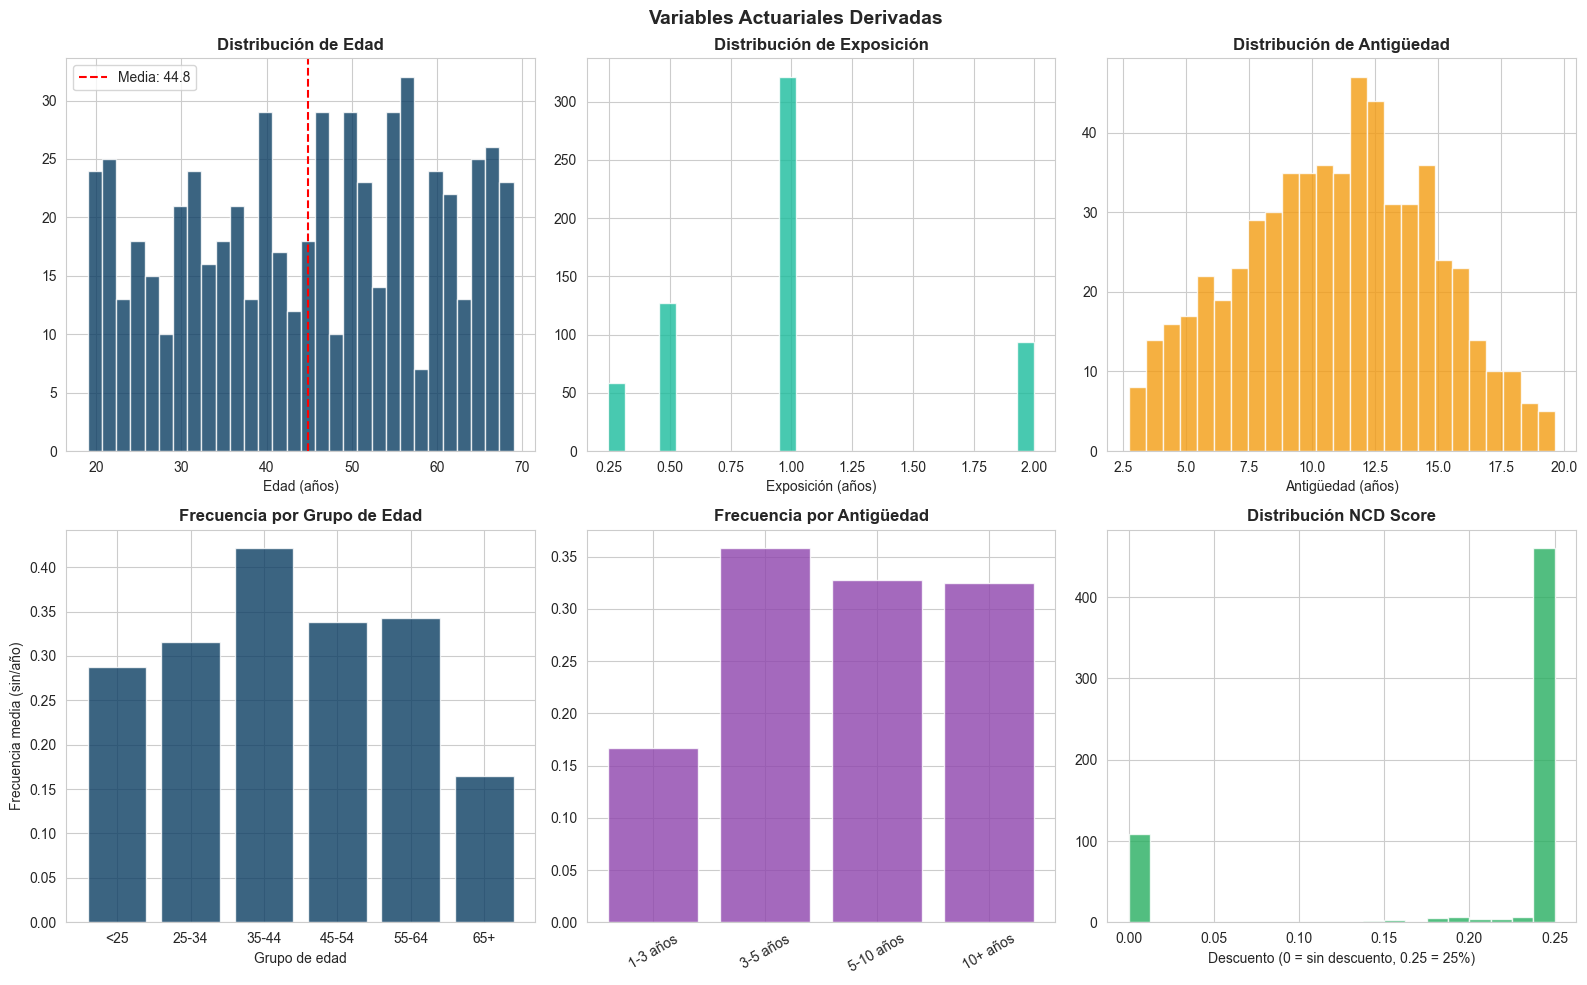

In [145]:
# Visualización de variables derivadas
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Distribución de edad
axes[0,0].hist(df['edad_cumplida'], bins=30, color='#0A3D62', alpha=0.8, edgecolor='white')
axes[0,0].set_title('Distribución de Edad', fontweight='bold')
axes[0,0].set_xlabel('Edad (años)')
axes[0,0].axvline(df['edad_cumplida'].mean(), color='red', ls='--', label=f"Media: {df['edad_cumplida'].mean():,.1f}")
axes[0,0].legend()

# Distribución de exposición
axes[0,1].hist(df['exposicion_anios'], bins=25, color='#1ABC9C', alpha=0.8, edgecolor='white')
axes[0,1].set_title('Distribución de Exposición', fontweight='bold')
axes[0,1].set_xlabel('Exposición (años)')

# Distribución de antigüedad
axes[0,2].hist(df['antiguedad_anios'], bins=25, color='#F39C12', alpha=0.8, edgecolor='white')
axes[0,2].set_title('Distribución de Antigüedad', fontweight='bold')
axes[0,2].set_xlabel('Antigüedad (años)')

# Siniestros por grupo de edad
freq_edad = df.groupby('grupo_edad', observed=True)['frecuencia_siniestros'].mean()
axes[1,0].bar(freq_edad.index, freq_edad.values, color='#0A3D62', alpha=0.8)
axes[1,0].set_title('Frecuencia por Grupo de Edad', fontweight='bold')
axes[1,0].set_xlabel('Grupo de edad')
axes[1,0].set_ylabel('Frecuencia media (sin/año)')

# Siniestros por antigüedad
freq_ant = df.groupby('segmento_antiguedad', observed=True)['frecuencia_siniestros'].mean()
axes[1,1].bar(freq_ant.index, freq_ant.values, color='#8E44AD', alpha=0.8)
axes[1,1].set_title('Frecuencia por Antigüedad', fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=30)

# NCD Score distribution
axes[1,2].hist(df['ncd_score'], bins=20, color='#27AE60', alpha=0.8, edgecolor='white')
axes[1,2].set_title('Distribución NCD Score', fontweight='bold')
axes[1,2].set_xlabel('Descuento (0 = sin descuento, 0.25 = 25%)')

plt.suptitle('Variables Actuariales Derivadas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('variables_actuariales.png', dpi=120, bbox_inches='tight')
plt.show()

Ejercicio:

Base de 800 pólizas, generar fecha de inicio de vigencia con el 1 de enero de 2025. Calcular la exposición en 2026, hasta el día de hoy y calcular la exposición promedio de la cartera

In [146]:
df_ejercicio

,id_poliza,municipio,tipo_cobertura,nivel_riesgo,marca_auto,sexo,prima_anual,siniestros,nivel_riesgo_encoded,municipio_le_incorrecto
0,1,Apodaca,Básica,Medio,Kia,M,5000.000000,0,1,0
1,2,San Pedro,Amplia,Bajo,Toyota,M,25834.686904,0,0,6
2,3,Monterrey,Básica,Bajo,Ford,M,26231.886178,0,0,5
3,4,Guadalupe,Total,Medio,Seat,M,14415.961442,1,1,3
4,5,Escobedo,Total,Alto,Nissan,M,19146.489391,0,2,1
...,...,...,...,...,...,...,...,...,...,...
795,796,Monterrey,Amplia,Bajo,Kia,F,25702.085305,0,0,5
796,797,Guadalupe,Amplia,Bajo,Nissan,M,18166.466603,0,0,3
797,798,San Pedro,Básica,Bajo,Volkswagen,F,47018.750241,0,0,6
798,799,San Pedro,Amplia,Bajo,Honda,M,27662.298838,1,0,6


In [147]:
# Crear dataset de pólizas con fechas
np.random.seed(42)
n = 800
fecha_base = pd.Timestamp('2025-01-01')
fecha_actual = pd.Timestamp(datetime.now().date())

# Generar fechas aleatorias
def fecha_aleatoria(inicio, fin, n):
    rango = (fin - inicio).days
    dias = np.random.randint(0, rango, n)
    return pd.to_datetime([inicio + timedelta(days=int(d)) for d in dias])

fechas_nacimiento = fecha_aleatoria(pd.Timestamp('1955-01-01'), pd.Timestamp('2005-12-31'), n)
fechas_inicio_poliza = fecha_aleatoria(fecha_base, pd.Timestamp('2025-06-01'), n)
duración_dias = np.random.choice([365, 180, 90, 730], n, p=[0.55, 0.20, 0.10, 0.15])
fechas_fin_poliza = fechas_inicio_poliza + pd.to_timedelta(duración_dias, unit='d')
fechas_primer_poliza = fechas_inicio_poliza - pd.to_timedelta(np.random.randint(0, 3650, n), unit='d')

df_ejercicio["fecha_nacimiento"] = fechas_nacimiento
df_ejercicio["fecha_inicio_poliza"] = fechas_inicio_poliza
df_ejercicio["fecha_fin_poliza"] = fechas_fin_poliza
df_ejercicio["fecha_primera_poliza"] = fechas_primer_poliza

df_ejercicio

,id_poliza,municipio,tipo_cobertura,nivel_riesgo,marca_auto,sexo,prima_anual,siniestros,nivel_riesgo_encoded,municipio_le_incorrecto,fecha_nacimiento,fecha_inicio_poliza,fecha_fin_poliza,fecha_primera_poliza
0,1,Apodaca,Básica,Medio,Kia,M,5000.000000,0,1,0,1998-03-31,2025-04-11,2026-04-11,2022-09-06
1,2,San Pedro,Amplia,Bajo,Toyota,M,25834.686904,0,0,6,1957-05-10,2025-03-14,2025-09-10,2015-12-19
2,3,Monterrey,Básica,Bajo,Ford,M,26231.886178,0,0,5,1969-10-04,2025-01-17,2026-01-17,2019-07-09
3,4,Guadalupe,Total,Medio,Seat,M,14415.961442,1,1,3,1987-10-04,2025-01-09,2025-04-09,2023-10-08
4,5,Escobedo,Total,Alto,Nissan,M,19146.489391,0,2,1,1985-11-23,2025-05-23,2026-05-23,2015-11-20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,796,Monterrey,Amplia,Bajo,Kia,F,25702.085305,0,0,5,2005-07-01,2025-03-11,2025-09-07,2023-10-06
796,797,Guadalupe,Amplia,Bajo,Nissan,M,18166.466603,0,0,3,1969-06-23,2025-05-25,2026-05-25,2020-06-12
797,798,San Pedro,Básica,Bajo,Volkswagen,F,47018.750241,0,0,6,1959-06-08,2025-05-03,2026-05-03,2015-09-10
798,799,San Pedro,Amplia,Bajo,Honda,M,27662.298838,1,0,6,1978-04-22,2025-03-30,2026-03-30,2024-01-25


In [148]:
# Calcular edad correctamente
FECHA_EVALUACION = fecha_actual

# Edad en años decimales (más preciso)
df_ejercicio['edad_anios'] = (FECHA_EVALUACION - df_ejercicio['fecha_nacimiento']).dt.days / 365.25

# Edad en años completos
df_ejercicio['edad_cumplida'] = df_ejercicio['edad_anios'].astype(int)

# Verificar
print("📊 Edad calculada:")
print(df_ejercicio[['fecha_nacimiento', 'edad_anios', 'edad_cumplida']].head(8).to_string(index=False))
print(f"\n📈 Distribución de edades:")
print(f"  Mínima: {df_ejercicio['edad_cumplida'].min()} años")
print(f"  Máxima: {df_ejercicio['edad_cumplida'].max()} años")
print(f"  Promedio: {df_ejercicio['edad_anios'].mean():.1f} años")

# Segmentación por grupos de edad (estándar actuarial)
bins_edad = [0, 25, 35, 45, 55, 65, 200]
labels_edad = ['<25', '25-34', '35-44', '45-54', '55-64', '65+']
df_ejercicio['grupo_edad'] = pd.cut(df_ejercicio['edad_cumplida'], bins=bins_edad, labels=labels_edad, right=False)
print("\n👥 Distribución por grupo de edad:")
print(df_ejercicio['grupo_edad'].value_counts().sort_index())

📊 Edad calculada:
fecha_nacimiento  edad_anios  edad_cumplida
      1998-03-31   28.145106             28
      1957-05-10   69.034908             69
      1969-10-04   56.632444             56
      1987-10-04   38.633812             38
      1985-11-23   40.495551             40
      1972-02-26   54.236824             54
      2001-02-18   25.256674             25
      1967-02-13   59.271732             59

📈 Distribución de edades:
  Mínima: 20 años
  Máxima: 71 años
  Promedio: 46.2 años

👥 Distribución por grupo de edad:
grupo_edad
<25       78
25-34    141
35-44    153
45-54    167
55-64    165
65+       96
Name: count, dtype: int64


In [159]:
# Calcular exposición (tiempo bajo cobertura)
# Exposición en días
periodo_inicial_de_estudio = pd.Timestamp('2026-01-01')
start = df_ejercicio['fecha_inicio_poliza'].mask(df_ejercicio['fecha_inicio_poliza'] < periodo_inicial_de_estudio, periodo_inicial_de_estudio)
end = df_ejercicio['fecha_fin_poliza'].mask(df_ejercicio['fecha_fin_poliza'] > fecha_actual, fecha_actual)
df_ejercicio['exposicion_dias_2026'] = (end - start).dt.days.clip(lower=0)

# Exposición en años (estándar actuarial)
df_ejercicio['exposicion_anios'] = df_ejercicio['exposicion_dias_2026'] / 365.25

# Frecuencia ajustada por exposición
df_ejercicio['frecuencia_siniestros'] = np.where(
    df_ejercicio['exposicion_anios'] > 0,
    df_ejercicio['siniestros'] / df_ejercicio['exposicion_anios'],
    0
)

print("📊 Variables de exposición:")
print(df_ejercicio[['id_poliza', 'fecha_inicio_poliza', 'fecha_fin_poliza', 
          'exposicion_dias_2026', 'exposicion_anios', 'siniestros', 'frecuencia_siniestros']].head(8).to_string(index=False))

print(f"\n📈 Estadísticas de exposición:")
print(f"  Exposición total del portafolio: {df_ejercicio['exposicion_anios'].sum():.1f} póliza-años")
print(f"  Exposición promedio por póliza: {df_ejercicio['exposicion_anios'].mean():.3f} años ({df_ejercicio['exposicion_dias_2026'].mean():.0f} días)")
print(f"  Frecuencia media: {df_ejercicio['frecuencia_siniestros'].mean():.4f} siniestros/año")

📊 Variables de exposición:
 id_poliza fecha_inicio_poliza fecha_fin_poliza  exposicion_dias_2026  exposicion_anios  siniestros  frecuencia_siniestros
         1          2025-04-11       2026-04-11                   100          0.273785           0                    0.0
         2          2025-03-14       2025-09-10                     0          0.000000           0                    0.0
         3          2025-01-17       2026-01-17                    16          0.043806           0                    0.0
         4          2025-01-09       2025-04-09                     0          0.000000           1                    0.0
         5          2025-05-23       2026-05-23                   142          0.388775           0                    0.0
         6          2025-02-07       2027-02-07                   142          0.388775           0                    0.0
         7          2025-04-04       2026-04-04                    93          0.254620           0             

In [150]:
df_ejercicio.describe()

,id_poliza,prima_anual,siniestros,nivel_riesgo_encoded,municipio_le_incorrecto,fecha_nacimiento,fecha_inicio_poliza,fecha_fin_poliza,fecha_primera_poliza,edad_anios,edad_cumplida,exposicion_dias,exposicion_anios,frecuencia_siniestros
count,800.0000,800.000000,800.000000,800.000000,800.000000,800,800,800,800,800.000000,800.000000,800.000000,800.000000,800.000000
mean,400.5000,20494.485567,0.250000,0.746250,3.700000,1980-03-02 04:06:36,2025-03-14 21:03:35.999999744,2026-02-24 10:24:36,2020-02-19 04:28:12,46.222666,45.721250,434.122500,1.188563,0.212453
min,1.0000,5000.000000,0.000000,0.000000,0.000000,1955-01-10 00:00:00,2025-01-01 00:00:00,2025-04-03 00:00:00,2015-02-05 00:00:00,20.495551,20.000000,357.000000,0.977413,0.000000
25%,200.7500,12805.944415,0.000000,0.000000,2.000000,1968-03-21 12:00:00,2025-02-06 00:00:00,2025-10-09 06:00:00,2017-10-10 00:00:00,33.863792,33.000000,397.000000,1.086927,0.000000
50%,400.5000,18169.797349,0.000000,1.000000,4.000000,1979-01-06 00:00:00,2025-03-13 00:00:00,2026-02-20 00:00:00,2020-03-11 12:00:00,47.375770,47.000000,436.000000,1.193703,0.000000
75%,600.2500,25395.869964,0.000000,1.000000,5.000000,1992-07-11 06:00:00,2025-04-21 00:00:00,2026-04-30 06:00:00,2022-06-19 06:00:00,58.169747,58.000000,471.000000,1.289528,0.000000
max,800.0000,97500.161349,3.000000,2.000000,7.000000,2005-11-23 00:00:00,2025-05-31 00:00:00,2027-05-31 00:00:00,2025-05-27 00:00:00,71.364819,71.000000,507.000000,1.388090,2.204728
std,231.0844,10853.367022,0.485071,0.773051,2.144936,NaN,NaN,NaN,NaN,14.493883,14.512988,43.799863,0.119917,0.413637


In [155]:
# Calcular antigüedad
df_ejercicio['antiguedad_anios'] = (FECHA_EVALUACION - df_ejercicio['fecha_primera_poliza']).dt.days / 365.25
df_ejercicio['antiguedad_anios'] = df_ejercicio['antiguedad_anios'].clip(lower=0)

# Segmentación por antigüedad
bins_ant = [0, 1, 3, 5, 10, 100]
labels_ant = ['<1 año', '1-3 años', '3-5 años', '5-10 años', '10+ años']
df_ejercicio['segmento_antiguedad'] = pd.cut(df_ejercicio['antiguedad_anios'], bins=bins_ant, labels=labels_ant)

# Análisis de siniestralidad por antigüedad
analisis_ant = df_ejercicio.groupby('segmento_antiguedad', observed=True).agg(
    n_polizas=('id_poliza', 'count'),
    siniestros_total=('siniestros', 'sum'),
    exposicion_total=('exposicion_anios', 'sum'),
    prima_media=('monto_siniestros', 'mean')
).round(3)
analisis_ant['frecuencia'] = (analisis_ant['siniestros_total'] / analisis_ant['exposicion_total']).round(4)

print("📊 Siniestralidad por Antigüedad:")
print(analisis_ant.to_string())
print("\n💡 Observa si los clientes más antiguos tienen menor frecuencia de siniestros")

KeyError: "Column(s) ['monto_siniestros'] do not exist"